In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def sample_image(image, factor):
    height, width= image.shape[:2]
    sampled_image= cv2.resize(image, (width // factor, height // factor), interpolation= cv2.INTER_NEAREST)
    
    return sampled_image

def quantize_image(image, levels):
    quantized_image= np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image= quantized_image.astype(np.uint8)
    
    return quantized_image

def plot_images(original, sampled, quantized):
    plt.figure(figsize= (12, 4))
    
    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap= "gray")
    plt.title("Original Image")
    plt.axis("off")
    
    # Sampled Image
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap= "gray")
    plt.title("Sampled Image")
    plt.axis("off")
    
    # Quantized Image
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap= "gray")
    plt.title("Quantized Image")
    plt.axis("off")
    
    plt.show()

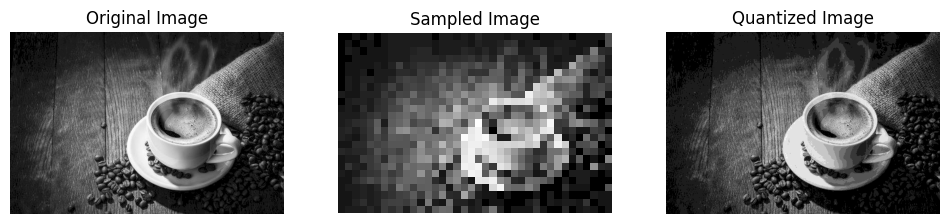

In [6]:
image_path= "./images/image.png"

sampling_factor= 14
quantization_levels= 9

original_image= cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

sampled_image= sample_image(original_image, sampling_factor)
quantized_image= quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

In [10]:
from PIL import Image

img1= Image.open('./images/task1v1.png')
img2= Image.open('./images/task1v2.png')

resize= (400, 400)
img1= img1.resize(resize, Image.Resampling.LANCZOS)
img2= img2.resize(resize, Image.Resampling.LANCZOS)

im1arr= np.asarray(img1, dtype= np.uint16)
im2arr= np.asarray(img2, dtype= np.uint16)

addition= np.clip(im1arr + im2arr, 0, 255).astype(np.uint8)

resultImage= Image.fromarray(addition)
resultImage.show()

In [14]:
img3= Image.open('./images/task2v1.png')
img4= Image.open('./images/task2v2.png')

img3.show()
img4.show()

img3= img3.resize(resize, Image.Resampling.LANCZOS)
img4= img4.resize(resize, Image.Resampling.LANCZOS)

im3arr= np.asarray(img3)
im4arr= np.asarray(img4)

union= im4arr | im3arr

resultImage2= Image.fromarray(union)
resultImage2.show()

# Task#1

In [16]:
def sample_and_quantize(image_path, scale_factor= 0.25, bits= 2):
    img= Image.open(image_path).convert('L')
    orig_w, orig_h= img.size
    
    new_w, new_h= max(1, int(orig_w * scale_factor)), max(1, int(orig_h * scale_factor))
    sampled_img= img.resize((new_w, new_h), Image.Resampling.NEAREST)
    sampled_restored= sampled_img.resize((orig_w, orig_h), Image.Resampling.NEAREST)
    
    levels= 2 ** bits
    arr= np.asarray(sampled_restored, dtype=np.float32)
    quantized_arr= np.floor(arr / (256.0 / levels)) * (255.0 / (levels - 1))
    quantized_img= Image.fromarray(quantized_arr.astype(np.uint8))
    
    return quantized_img

degraded_img= sample_and_quantize('./images/task1v2.png', scale_factor= 0.25, bits= 2)
degraded_img.show()

# Task#2

In [18]:
img1= Image.open('./images/task1v1.png').convert('L')
img2= Image.open('./images/task1v2.png').convert('L')

resize_dim= (400, 400)
img1= img1.resize(resize_dim, Image.Resampling.LANCZOS)
img2= img2.resize(resize_dim, Image.Resampling.LANCZOS)

# Convert to float/int32 to prevent underflow/overflow during calculations
X= np.asarray(img1, dtype= np.int32)
Y= np.asarray(img2, dtype= np.int32)

# 1. Subtract two images. Absolute difference |X - Y| (or clip to 0: np.clip(X - Y, 0, 255))
subtraction= np.abs(X - Y).astype(np.uint8)
Image.fromarray(subtraction).show()

# 2. Add constant value (175). Brightens image, clipped to max saturation (255)
addition_const= np.clip(X + 175, 0, 255).astype(np.uint8)
Image.fromarray(addition_const).show()

# 3. Set Difference: X \ Y
complement_Y= 255 - Y
set_difference= np.minimum(X, complement_Y).astype(np.uint8)
Image.fromarray(set_difference).show()

# 4. Symmetric Difference: (X \ Y) U (Y \ X)
complement_X= 255 - X
diff_X_Y= np.minimum(X, complement_Y)
diff_Y_X= np.minimum(Y, complement_X)
symmetric_difference= np.maximum(diff_X_Y, diff_Y_X).astype(np.uint8)
Image.fromarray(symmetric_difference).show()

# 5. Intersection: X ∩ Y
intersection= np.minimum(X, Y).astype(np.uint8)
Image.fromarray(intersection).show()